In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [2]:
verified_df = pd.read_csv("Verified_Train_Dataset.csv")

print("Dataset Shape:", verified_df.shape)
verified_df.head()

Dataset Shape: (186074, 12)


,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [3]:
verified_df['Arrival_time'] = pd.to_datetime(
    verified_df['Arrival_time'],
    errors='coerce'
)

verified_df['Departure_Time'] = pd.to_datetime(
    verified_df['Departure_Time'],
    errors='coerce'
)

/var/folders/0c/7f8p6mvs5mg8nbh9mllqtkb80000gn/T/ipykernel_1966/3393747427.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  verified_df['Arrival_time'] = pd.to_datetime(
/var/folders/0c/7f8p6mvs5mg8nbh9mllqtkb80000gn/T/ipykernel_1966/3393747427.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  verified_df['Departure_Time'] = pd.to_datetime(


In [4]:
journey_duration = (
    verified_df.sort_values(['Train_No','SN'])
    .groupby('Train_No')
    .agg(
        Start_Time=('Departure_Time','first'),
        End_Time=('Arrival_time','last')
    )
)

journey_duration['Duration_Hours'] = (
    (journey_duration['End_Time']
     - journey_duration['Start_Time'])
    .dt.total_seconds()/3600
)

journey_duration.loc[
    journey_duration['Duration_Hours'] < 0,
    'Duration_Hours'
] += 24

journey_duration = journey_duration.reset_index()

In [5]:
route_distance = (
    verified_df.groupby('Train_No')['Distance']
    .max()
    .reset_index(name='Route_Distance')
)

In [6]:
def classify_route(distance):

    if distance < 300:
        return 'Short'

    elif distance < 800:
        return 'Medium'

    else:
        return 'Long'

route_distance['Route_Type'] = (
    route_distance['Route_Distance']
    .apply(classify_route)
)

In [7]:
duration_analysis = pd.merge(
    journey_duration,
    route_distance[['Train_No','Route_Type']],
    on='Train_No'
)

duration_analysis.head()

,Train_No,Start_Time,End_Time,Duration_Hours,Route_Type
0,107,2026-06-02 10:25:00,2026-06-02 12:10:00,1.750000,Short
1,108,2026-06-02 20:30:00,2026-06-02 22:25:00,1.916667,Short
2,128,2026-06-02 19:40:00,2026-06-02 17:45:00,22.083333,Long
3,290,2026-06-02 18:30:00,2026-06-02 02:30:00,8.000000,Long
4,401,2026-06-02 21:30:00,2026-06-02 10:00:00,12.500000,Long


In [8]:
avg_duration = (
    duration_analysis.groupby('Route_Type')
    ['Duration_Hours']
    .mean()
    .reset_index()
)

print(avg_duration)

  Route_Type  Duration_Hours
0       Long       12.149633
1     Medium       11.140849
2      Short        2.109644


In [9]:
station_traffic = (
    verified_df.groupby(
        ['Station_Code','Station_Name']
    )
    .size()
    .reset_index(name='Train_Count')
    .sort_values(
        'Train_Count',
        ascending=False
    )
)

station_traffic.head(10)

,Station_Code,Station_Name,Train_Count
1713,CSMT,CST-MUMBAI,1027
4254,KYN,KALYAN JN,828
7602,TNA,THANE,796
6649,SDAH,SEALDAH,745
5030,MSB,CHENNAI BEAC,738
2979,HWH,HOWRAH JN.,699
2130,DR,DADAR,567
1843,DDJ,DUM DUM JN.,463
1592,CLA,KURLA,462
7395,TBM,TAMBARAM,434


In [10]:
top10_stations = station_traffic.head(10)

print(top10_stations)

     Station_Code  Station_Name  Train_Count
1713         CSMT    CST-MUMBAI         1027
4254          KYN     KALYAN JN          828
7602          TNA         THANE          796
6649         SDAH       SEALDAH          745
5030          MSB  CHENNAI BEAC          738
2979          HWH    HOWRAH JN.          699
2130           DR         DADAR          567
1843          DDJ   DUM DUM JN.          463
1592          CLA         KURLA          462
7395          TBM      TAMBARAM          434


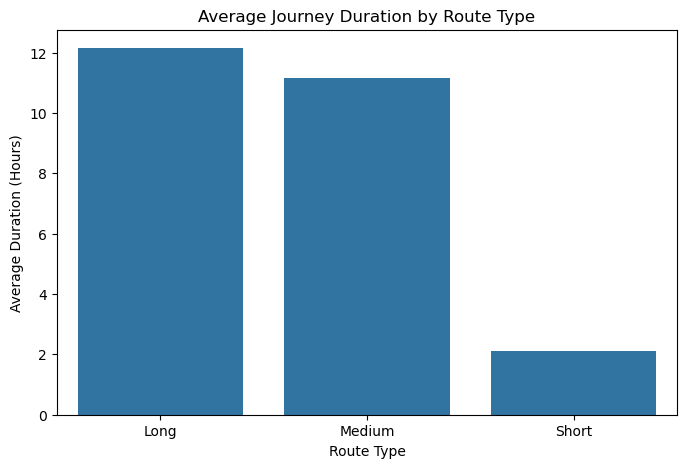

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_duration,
    x='Route_Type',
    y='Duration_Hours'
)

plt.title('Average Journey Duration by Route Type')
plt.xlabel('Route Type')
plt.ylabel('Average Duration (Hours)')
plt.show()

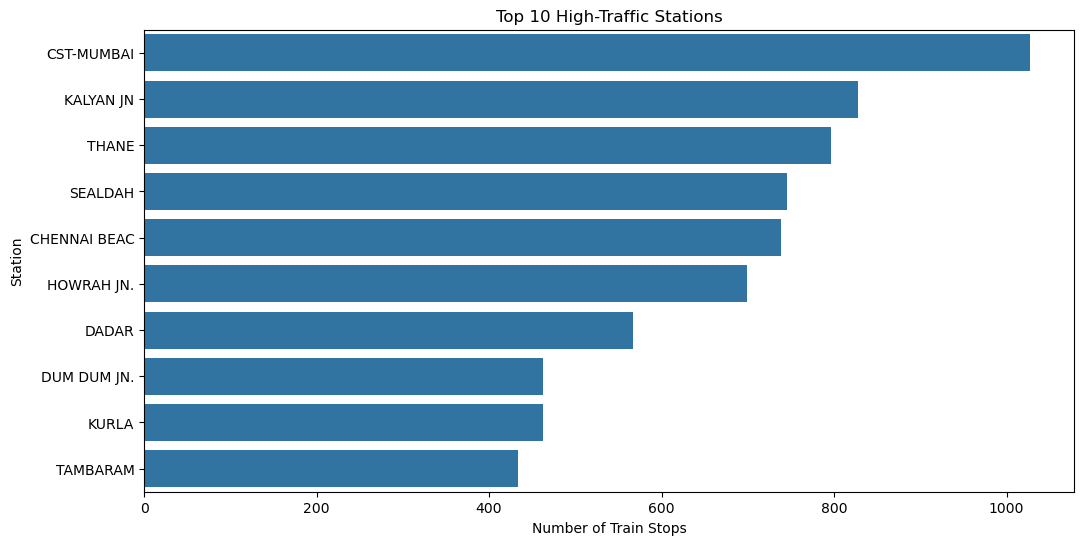

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_stations,
    x='Train_Count',
    y='Station_Name'
)

plt.title('Top 10 High-Traffic Stations')
plt.xlabel('Number of Train Stops')
plt.ylabel('Station')
plt.show()

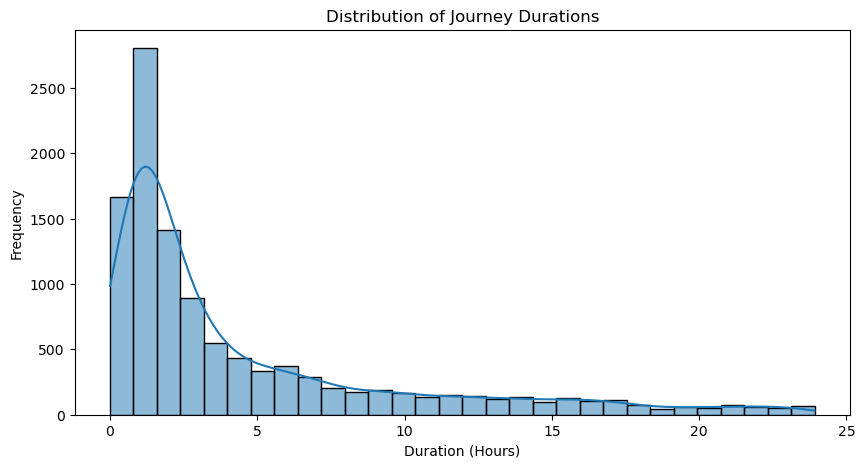

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    duration_analysis['Duration_Hours'],
    bins=30,
    kde=True
)

plt.title('Distribution of Journey Durations')
plt.xlabel('Duration (Hours)')
plt.ylabel('Frequency')
plt.show()

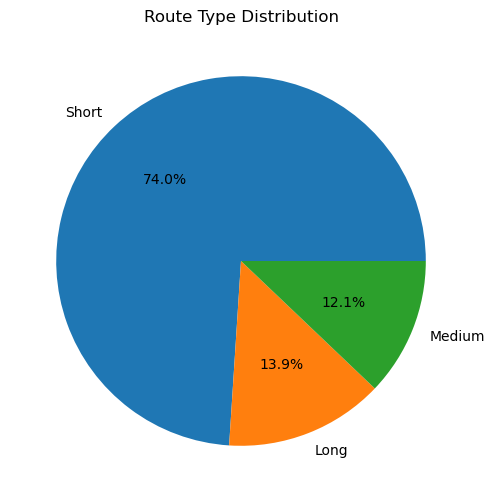

In [14]:
plt.figure(figsize=(6,6))

route_distance['Route_Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Route Type Distribution')
plt.show()

In [15]:
print("===== KEY OBSERVATIONS =====")

print("\n1. Average Journey Duration")
print(avg_duration)

print("\n2. Most Crowded Station")
print(top10_stations.iloc[0])

print("\n3. Total Stations")
print(
    verified_df['Station_Name']
    .nunique()
)

print("\n4. Total Trains")
print(
    verified_df['Train_No']
    .nunique()
)

===== KEY OBSERVATIONS =====

1. Average Journey Duration
  Route_Type  Duration_Hours
0       Long       12.149633
1     Medium       11.140849
2      Short        2.109644

2. Most Crowded Station
Station_Code          CSMT
Station_Name    CST-MUMBAI
Train_Count           1027
Name: 1713, dtype: object

3. Total Stations
8099

4. Total Trains
11113
